In [57]:
import scipy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [63]:
file = 'CH368_ProblemSet2_Periodic_Function.txt'

In [64]:
column_names = ['Time (s)', 'Amplitude']
df = pd.read_csv(file, sep='\t', names=column_names)
df

,Time (s),Amplitude
0,-10.00,-4.013016
1,-9.99,0.041981
2,-9.98,-3.130847
3,-9.97,3.951577
4,-9.96,1.925055
...,...,...
1996,9.96,-2.295230
1997,9.97,1.316825
1998,9.98,0.396562
1999,9.99,1.270186


<Axes: xlabel='Time (s)', ylabel='Amplitude'>

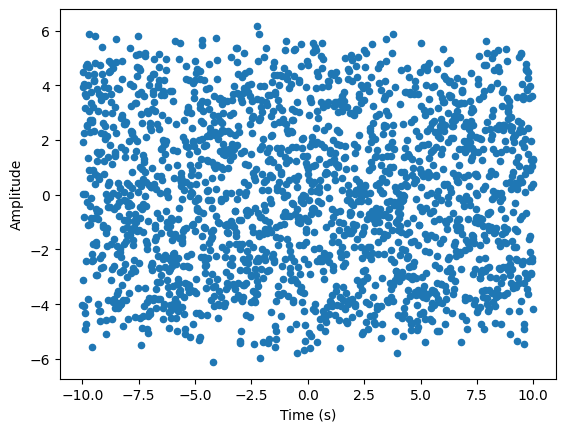

In [65]:
df.plot(kind='scatter', x='Time (s)', y='Amplitude')

In [75]:
signal = df["Amplitude"].values
time = df["Time (s)"].values


In [76]:
# compute fft
fft_values = np.fft.fft(df["Amplitude"].values)
dt = df["Time (s)"].values[1] - df["Time (s)"].values[0]
freqs = np.fft.fftfreq(n, d=dt)
df['frequency'] = freqs
fft_magnitude = np.abs(fft_values)
df['fft magnitude'] = fft_magnitude

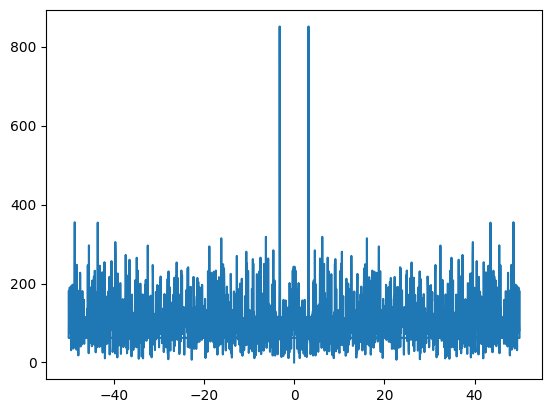

In [77]:
plt.plot(freqs, fft_magnitude)

Dominant freq: 3.1984007996002686


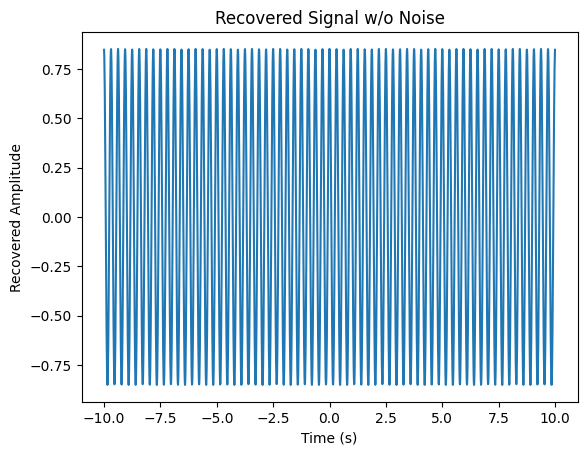

In [80]:
# only look at positive frequencies to find the dominant one
positive_mask = freqs > 0
positive_freqs = freqs[positive_mask]
positive_magnitude = fft_magnitude[positive_mask]

peak_index_pos = np.argmax(positive_magnitude)
dominant_frequency = positive_freqs[peak_index_pos]
print("Dominant freq:", dominant_frequency)

# get the index in the full fft array
peak_index = np.where(freqs == dominant_frequency)[0][0]
mirror_index = np.where(freqs == -dominant_frequency)[0][0]

# keep only the two dominant peaks
filtered_fft = np.zeros_like(fft_values, dtype=complex)
filtered_fft[peak_index] = fft_values[peak_index]
filtered_fft[mirror_index] = fft_values[mirror_index]

# inverse fft to recover clean signal
recovered_signal = np.fft.ifft(filtered_fft).real

# plot recovered signal vs time
plt.figure()
plt.plot(time, recovered_signal)
plt.xlabel("Time (s)")
plt.ylabel("Recovered Amplitude")
plt.title("Recovered Signal w/o Noise")
plt.show()